In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras import layers, models

In [2]:
DATA_PATH = "Weather_Data.csv"
ARTIFACT_DIR = "artifacts"
WINDOW = 30

In [3]:
#Load the dataset

km = pd.read_csv(DATA_PATH)

print("Shape of dataset:", km.shape)
display(km.head())
km.info()

Shape of dataset: (3271, 17)


,Date,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
0,2/1/2008,19.5,22.4,15.6,6.2,0.0,41,17,20,92,84,1017.6,1017.4,8,8,20.7,20.9
1,2/2/2008,19.5,25.6,6.0,3.4,2.7,41,9,13,83,73,1017.9,1016.4,7,7,22.4,24.8
2,2/3/2008,21.6,24.5,6.6,2.4,0.1,41,17,2,88,86,1016.7,1015.6,7,8,23.5,23.0
3,2/4/2008,20.2,22.8,18.8,2.2,0.0,41,22,20,83,90,1014.2,1011.8,8,8,21.4,20.9
4,2/5/2008,19.7,25.7,77.4,4.8,0.0,41,11,6,88,74,1008.3,1004.8,8,8,22.5,25.5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3271 entries, 0 to 3270
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           3271 non-null   object 
 1   MinTemp        3271 non-null   float64
 2   MaxTemp        3271 non-null   float64
 3   Rainfall       3271 non-null   float64
 4   Evaporation    3271 non-null   float64
 5   Sunshine       3271 non-null   float64
 6   WindGustSpeed  3271 non-null   int64  
 7   WindSpeed9am   3271 non-null   int64  
 8   WindSpeed3pm   3271 non-null   int64  
 9   Humidity9am    3271 non-null   int64  
 10  Humidity3pm    3271 non-null   int64  
 11  Pressure9am    3271 non-null   float64
 12  Pressure3pm    3271 non-null   float64
 13  Cloud9am       3271 non-null   int64  
 14  Cloud3pm       3271 non-null   int64  
 15  Temp9am        3271 non-null   float64
 16  Temp3pm        3271 non-null   float64
dtypes: float64(9), int64(7), object(1)
memory usage: 434

In [4]:
#Basic preprocessing
#This step:
#converts Date into datetime
#sorts the rows by date
#keeps the dataset in proper time order

km["Date"] = pd.to_datetime(km["Date"], dayfirst=True, errors="coerce")
km = km.dropna(subset=["Date"]).sort_values("Date").reset_index(drop=True)

print("Shape after date parsing and sorting:", km.shape)
display(km.head())

Shape after date parsing and sorting: (1297, 17)


,Date,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
0,2008-01-02,19.5,22.4,15.6,6.2,0.0,41,17,20,92,84,1017.6,1017.4,8,8,20.7,20.9
1,2008-01-03,12.8,22.0,0.2,6.2,11.3,41,19,31,55,46,1020.9,1020.6,0,1,15.9,21.2
2,2008-01-04,13.7,23.9,0.0,6.6,11.0,41,20,15,55,54,1023.0,1021.5,1,1,16.7,23.3
3,2008-01-05,11.6,18.2,0.0,4.0,2.7,41,11,7,74,56,1019.7,1016.7,7,7,13.4,18.1
4,2008-01-06,11.6,20.5,0.2,2.2,0.3,41,19,17,91,74,1029.3,1027.0,7,7,14.3,18.7


In [5]:
#Inspect missing values
#Before modeling, we check whether the data has missing values.

missing_counts = km.isnull().sum().sort_values(ascending=False)
display(missing_counts[missing_counts > 0])

Series([], dtype: int64)

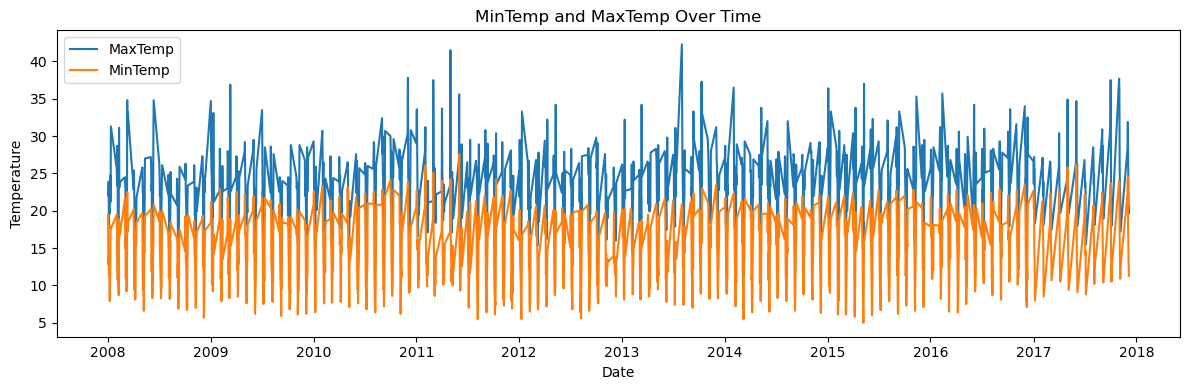

In [6]:
#Exploratory visuals
#These plots help you understand the data before training.
#MinTemp and MaxTemp over time
plt.figure(figsize=(12, 4))
plt.plot(km["Date"], km["MaxTemp"], label="MaxTemp")
plt.plot(km["Date"], km["MinTemp"], label="MinTemp")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.title("MinTemp and MaxTemp Over Time")
plt.legend()
plt.tight_layout()
plt.show()

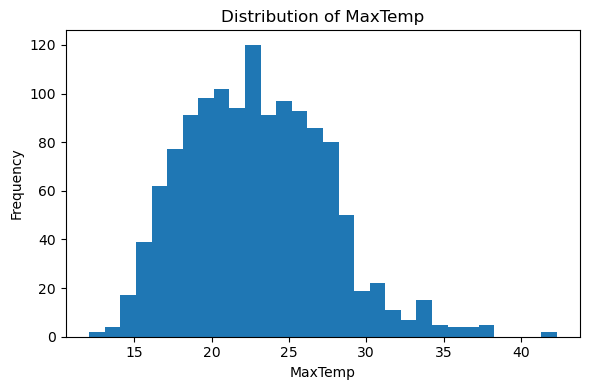

In [7]:
#Distribution of MaxTemp
plt.figure(figsize=(6, 4))
plt.hist(km["MaxTemp"].dropna(), bins=30)
plt.title("Distribution of MaxTemp")
plt.xlabel("MaxTemp")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

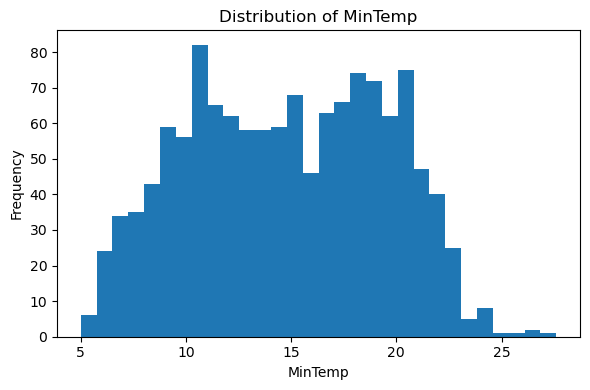

In [8]:
#Distribution of MinTemp
plt.figure(figsize=(6, 4))
plt.hist(km["MinTemp"].dropna(), bins=30)
plt.title("Distribution of MinTemp")
plt.xlabel("MinTemp")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

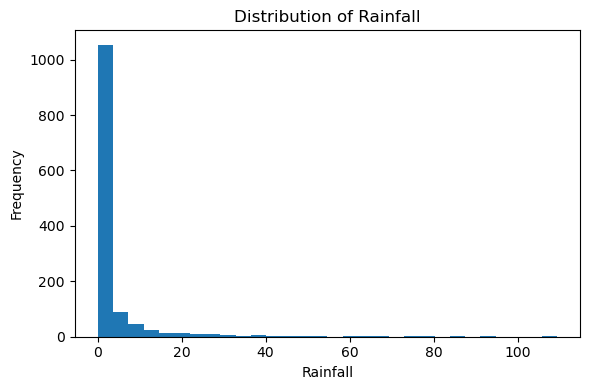

In [9]:
#Rainfall distribution
plt.figure(figsize=(6, 4))
plt.hist(km["Rainfall"].dropna(), bins=30)
plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

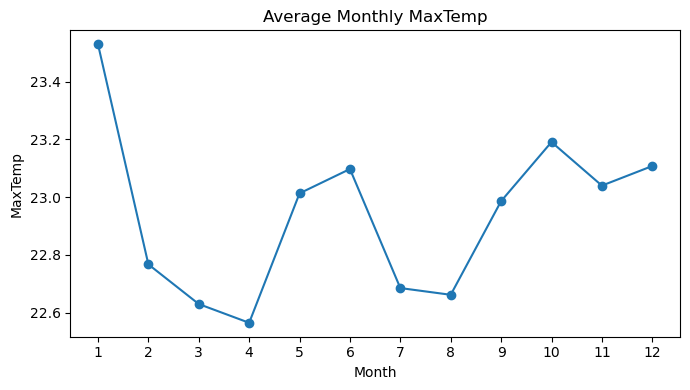

In [10]:
#Monthly average MaxTemp
#This helps show seasonality.
km_month = km.copy()
km_month["Month"] = km_month["Date"].dt.month
monthly_max = km_month.groupby("Month")["MaxTemp"].mean()

plt.figure(figsize=(7, 4))
plt.plot(monthly_max.index, monthly_max.values, marker="o")
plt.title("Average Monthly MaxTemp")
plt.xlabel("Month")
plt.ylabel("MaxTemp")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

In [11]:
#Clean missing values
#Because all your features are numeric, this is simple.
#We will:
#forward fill
#backward fill
#then use medians if anything still remains
numeric_cols = [
    "MinTemp", "MaxTemp", "Rainfall", "Evaporation", "Sunshine",
    "WindGustSpeed", "WindSpeed9am", "WindSpeed3pm",
    "Humidity9am", "Humidity3pm", "Pressure9am", "Pressure3pm",
    "Cloud9am", "Cloud3pm", "Temp9am", "Temp3pm"
]

for col in numeric_cols:
    km[col] = pd.to_numeric(km[col], errors="coerce")

km[numeric_cols] = km[numeric_cols].ffill().bfill()
km[numeric_cols] = km[numeric_cols].fillna(km[numeric_cols].median())

print("Remaining missing values:")
print(km[numeric_cols].isnull().sum().sum())

Remaining missing values:
0


In [12]:
#Feature engineering
#This step creates additional useful predictors.
#We will create:
#cyclical time features for seasonality
#average humidity
#average pressure
#average wind speed
#average cloud cover
#temperature range
km["DayOfYear"] = km["Date"].dt.dayofyear
km["Month"] = km["Date"].dt.month

km["doy_sin"] = np.sin(2 * np.pi * km["DayOfYear"] / 365.25)
km["doy_cos"] = np.cos(2 * np.pi * km["DayOfYear"] / 365.25)
km["mon_sin"] = np.sin(2 * np.pi * km["Month"] / 12)
km["mon_cos"] = np.cos(2 * np.pi * km["Month"] / 12)

km["TempRange"] = km["MaxTemp"] - km["MinTemp"]
km["HumidityMean"] = (km["Humidity9am"] + km["Humidity3pm"]) / 2.0
km["PressureMean"] = (km["Pressure9am"] + km["Pressure3pm"]) / 2.0
km["WindSpeedMean"] = (km["WindSpeed9am"] + km["WindSpeed3pm"]) / 2.0
km["CloudMean"] = (km["Cloud9am"] + km["Cloud3pm"]) / 2.0

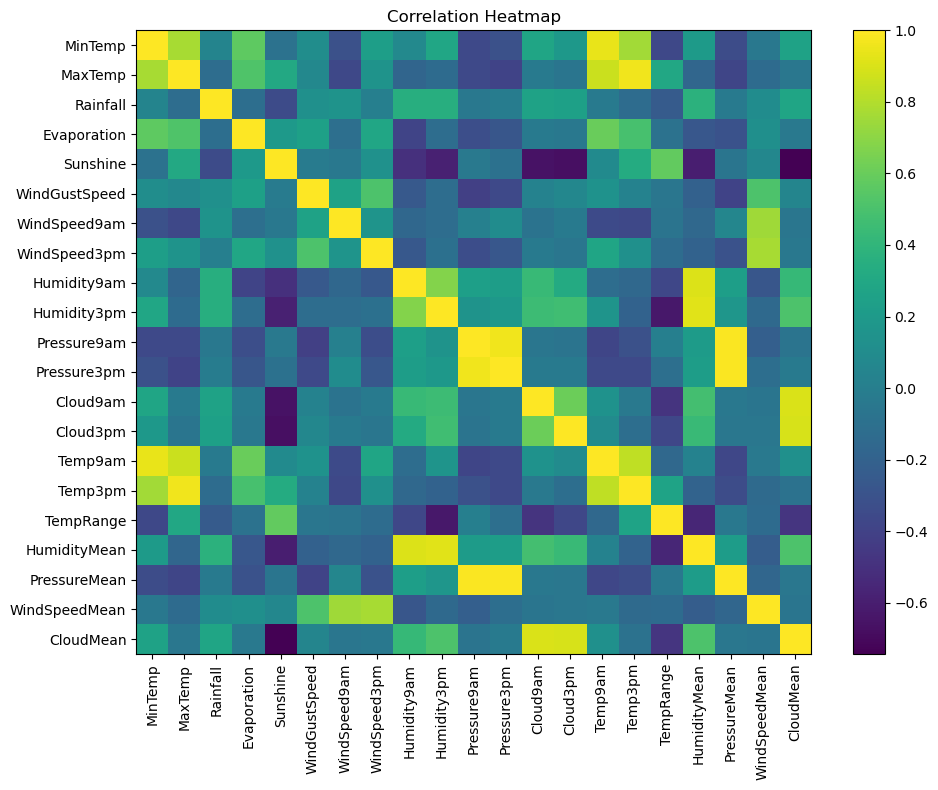

In [13]:
#Correlation heatmap

#This helps you see relationships among key variables.

corr_cols = [
    "MinTemp", "MaxTemp", "Rainfall", "Evaporation", "Sunshine",
    "WindGustSpeed", "WindSpeed9am", "WindSpeed3pm",
    "Humidity9am", "Humidity3pm", "Pressure9am", "Pressure3pm",
    "Cloud9am", "Cloud3pm", "Temp9am", "Temp3pm",
    "TempRange", "HumidityMean", "PressureMean", "WindSpeedMean", "CloudMean"
]

corr = km[corr_cols].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [14]:
#Create targets
#We want to predict tomorrow’s MaxTemp and MinTemp.
#So:
#NextMaxTemp = MaxTemp shifted by 1 day ahead
#NextMinTemp = MinTemp shifted by 1 day ahead

km["NextMaxTemp"] = km["MaxTemp"].shift(-1)
km["NextMinTemp"] = km["MinTemp"].shift(-1)

In [15]:
#Select features and build final modeling table
#We exclude:
#Date from model input
#the targets themselves from input

feature_cols = [
    "MinTemp", "MaxTemp", "Rainfall", "Evaporation", "Sunshine",
    "WindGustSpeed", "WindSpeed9am", "WindSpeed3pm",
    "Humidity9am", "Humidity3pm", "Pressure9am", "Pressure3pm",
    "Cloud9am", "Cloud3pm", "Temp9am", "Temp3pm",
    "doy_sin", "doy_cos", "mon_sin", "mon_cos",
    "TempRange", "HumidityMean", "PressureMean", "WindSpeedMean", "CloudMean"
]

km_model = km[feature_cols + ["NextMaxTemp", "NextMinTemp"]].dropna().reset_index(drop=True)

X_km = km_model[feature_cols].copy()
y_km = km_model[["NextMaxTemp", "NextMinTemp"]].copy()

print("X_km shape:", X_km.shape)
print("y_km shape:", y_km.shape)

X_km shape: (1296, 25)
y_km shape: (1296, 2)


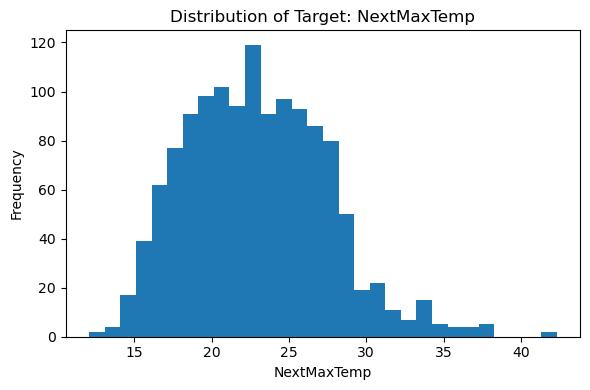

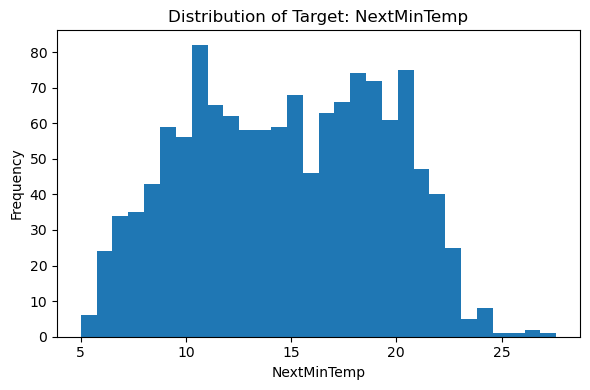

In [16]:
#Target visuals
plt.figure(figsize=(6, 4))
plt.hist(y_km["NextMaxTemp"], bins=30)
plt.title("Distribution of Target: NextMaxTemp")
plt.xlabel("NextMaxTemp")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(y_km["NextMinTemp"], bins=30)
plt.title("Distribution of Target: NextMinTemp")
plt.xlabel("NextMinTemp")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [17]:
#Scale the data
#Neural networks work better when inputs are scaled.

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_km_scaled = scaler_X.fit_transform(X_km.values)
y_km_scaled = scaler_y.fit_transform(y_km.values)

print("Scaling successful")
print(X_km_scaled.shape, y_km_scaled.shape)

Scaling successful
(1296, 25) (1296, 2)


In [18]:
#Generate sequences
#Now we convert the data into rolling windows of 30 days.
#Each example becomes:
#input = last 30 days of weather features
#output = tomorrow’s MaxTemp and MinTemp

def make_sequences(X, y, window=30):
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i-window:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_km_seq, y_km_seq = make_sequences(X_km_scaled, y_km_scaled, window=WINDOW)

print("X_km_seq shape:", X_km_seq.shape)
print("y_km_seq shape:", y_km_seq.shape)

X_km_seq shape: (1266, 30, 25)
y_km_seq shape: (1266, 2)


In [19]:
# Train/validation/test split
#We split chronologically.
n = len(X_km_seq)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train, y_train = X_km_seq[:train_end], y_km_seq[:train_end]
X_val, y_val = X_km_seq[train_end:val_end], y_km_seq[train_end:val_end]
X_test, y_test = X_km_seq[val_end:], y_km_seq[val_end:]

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (886, 30, 25) (886, 2)
Validation: (190, 30, 25) (190, 2)
Test: (190, 30, 25) (190, 2)


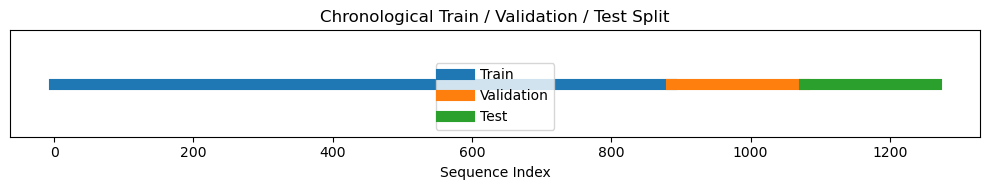

In [20]:
#Visualize the split
plt.figure(figsize=(10, 2))
plt.plot([0, train_end], [1, 1], linewidth=8, label="Train")
plt.plot([train_end, val_end], [1, 1], linewidth=8, label="Validation")
plt.plot([val_end, n], [1, 1], linewidth=8, label="Test")
plt.yticks([])
plt.xlabel("Sequence Index")
plt.title("Chronological Train / Validation / Test Split")
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
#Build CNN–GRU model
n_features = X_train.shape[2]

model = models.Sequential([
    layers.Input(shape=(WINDOW, n_features)),
    layers.Conv1D(filters=128, kernel_size=3, activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.30),

    layers.Conv1D(filters=64, kernel_size=3, activation="relu"),
    layers.Dropout(0.20),

    layers.GRU(64),
    layers.Dropout(0.30),

    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(2)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.Huber(),
    metrics=["mae"]
    )

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 28, 128)             │           9,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 28, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 14, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 14, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 12, 64)              │          24,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 12, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru (GRU)                            │ (None, 64)                  │          24,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 2)                   │              66 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 66,146 (258.38 KB)

 Trainable params: 65,890 (257.38 KB)

 Non-trainable params: 256 (1.00 KB)

In [24]:
#Train the model
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=12,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0399 - mae: 0.2147 - val_loss: 0.0539 - val_mae: 0.2819 - learning_rate: 0.0010
Epoch 2/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0157 - mae: 0.1383 - val_loss: 0.0597 - val_mae: 0.3008 - learning_rate: 0.0010
Epoch 3/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0132 - mae: 0.1265 - val_loss: 0.0587 - val_mae: 0.2987 - learning_rate: 0.0010
Epoch 4/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0107 - mae: 0.1128 - val_loss: 0.0513 - val_mae: 0.2768 - learning_rate: 0.0010
Epoch 5/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0106 - mae: 0.1138 - val_loss: 0.0536 - val_mae: 0.2847 - learning_rate: 0.0010
Epoch 6/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0105 - mae: 0.1137 - val_loss: 0.0460 - val_mae: 0.2606 - learning_rate: 0.0010
Epoch 7/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0098 - mae: 0.1097 - val_loss: 0.0403 - val_mae: 0.2434 - learning_rate: 0.0010
Epoch 8/150


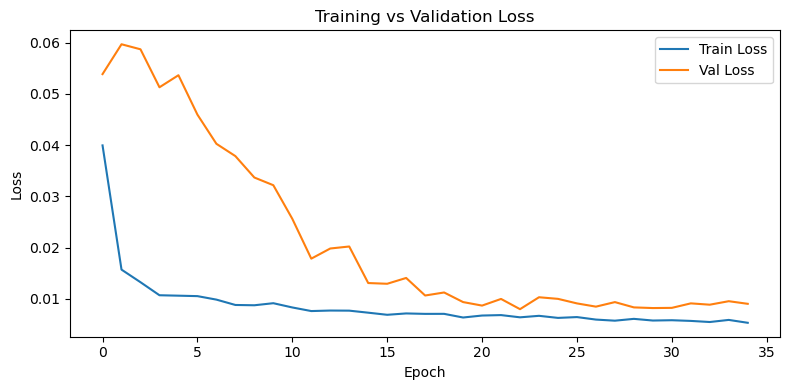

In [25]:
#Training visuals
#Loss
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

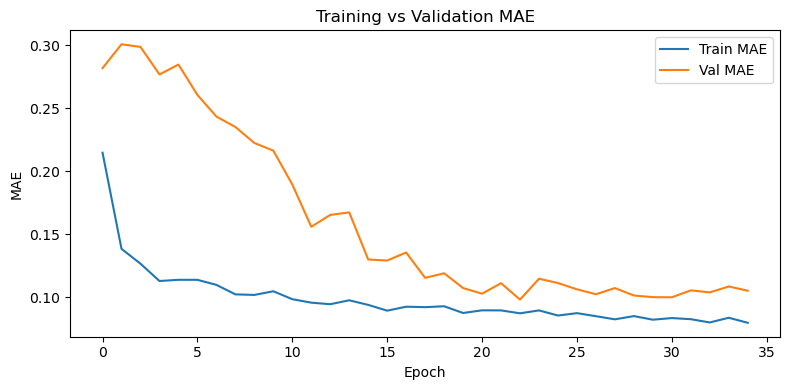

In [26]:
#MAE
plt.figure(figsize=(8, 4))
plt.plot(history.history["mae"], label="Train MAE")
plt.plot(history.history["val_mae"], label="Val MAE")
plt.title("Training vs Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
#Evaluate model
y_pred_scaled = model.predict(X_test, verbose=0)

y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

target_names = ["NextMaxTemp", "NextMinTemp"]

for i, name in enumerate(target_names):
    rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
    mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
    print(f"{name} RMSE: {rmse:.4f}")
    print(f"{name} MAE : {mae:.4f}")
    print("-" * 30)

NextMaxTemp RMSE: 5.3962
NextMaxTemp MAE : 3.9903
------------------------------
NextMinTemp RMSE: 5.2671
NextMinTemp MAE : 3.9580
------------------------------


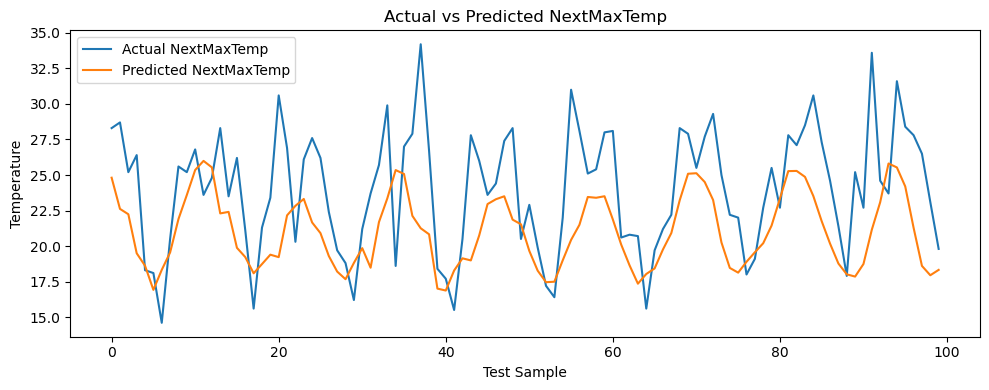

In [28]:
#Prediction visuals
#Actual vs predicted MaxTemp
plt.figure(figsize=(10, 4))
plt.plot(y_true[:100, 0], label="Actual NextMaxTemp")
plt.plot(y_pred[:100, 0], label="Predicted NextMaxTemp")
plt.title("Actual vs Predicted NextMaxTemp")
plt.xlabel("Test Sample")
plt.ylabel("Temperature")
plt.legend()
plt.tight_layout()
plt.show()

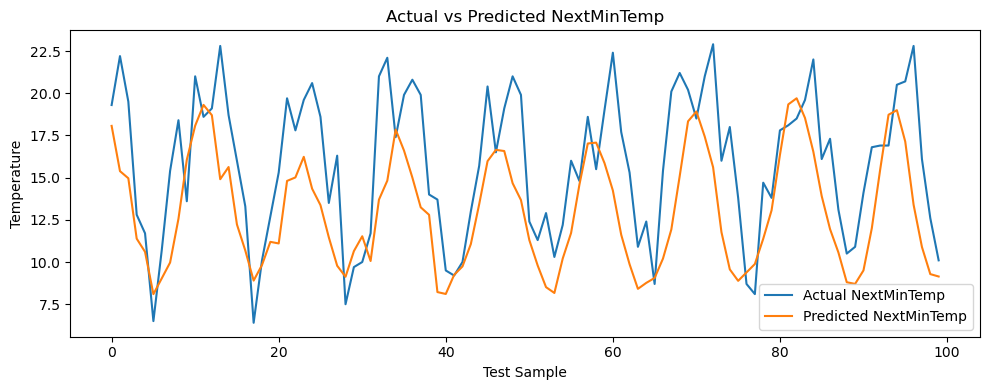

In [29]:
#Actual vs predicted MinTemp
plt.figure(figsize=(10, 4))
plt.plot(y_true[:100, 1], label="Actual NextMinTemp")
plt.plot(y_pred[:100, 1], label="Predicted NextMinTemp")
plt.title("Actual vs Predicted NextMinTemp")
plt.xlabel("Test Sample")
plt.ylabel("Temperature")
plt.legend()
plt.tight_layout()
plt.show()

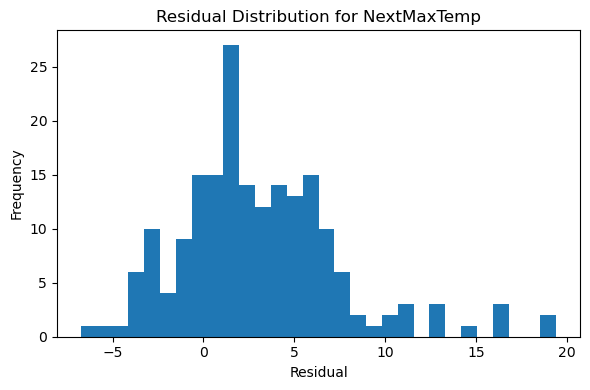

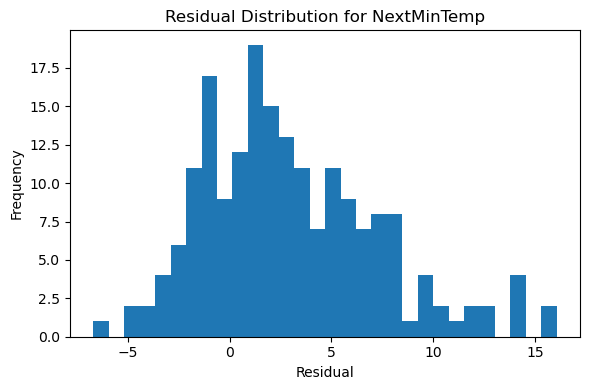

In [30]:
#Residuals
residual_max = y_true[:, 0] - y_pred[:, 0]
residual_min = y_true[:, 1] - y_pred[:, 1]

plt.figure(figsize=(6, 4))
plt.hist(residual_max, bins=30)
plt.title("Residual Distribution for NextMaxTemp")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(residual_min, bins=30)
plt.title("Residual Distribution for NextMinTemp")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [31]:
#Save model and artifacts
os.makedirs(ARTIFACT_DIR, exist_ok=True)

model.save(os.path.join(ARTIFACT_DIR, "cnn_gru_temp_model.keras"))
joblib.dump(scaler_X, os.path.join(ARTIFACT_DIR, "scaler_X.pkl"))
joblib.dump(scaler_y, os.path.join(ARTIFACT_DIR, "scaler_y.pkl"))
joblib.dump(feature_cols, os.path.join(ARTIFACT_DIR, "feature_cols.pkl"))

with open(os.path.join(ARTIFACT_DIR, "config.json"), "w") as f:
    json.dump({
        "window": WINDOW,
        "targets": ["NextMaxTemp", "NextMinTemp"]
    }, f, indent=2)

print("Artifacts saved successfully.")

Artifacts saved successfully.


In [32]:
#Test the model locally first
ARTIFACT_DIR = "artifacts"

model = tf.keras.models.load_model(os.path.join(ARTIFACT_DIR, "cnn_gru_temp_model.keras"))
scaler_X = joblib.load(os.path.join(ARTIFACT_DIR, "scaler_X.pkl"))
scaler_y = joblib.load(os.path.join(ARTIFACT_DIR, "scaler_y.pkl"))
feature_cols = joblib.load(os.path.join(ARTIFACT_DIR, "feature_cols.pkl"))

with open(os.path.join(ARTIFACT_DIR, "config.json"), "r") as f:
    config = json.load(f)

WINDOW = config["window"]

print("Artifacts loaded successfully")
print("Window:", WINDOW)
print("Targets:", config["targets"])

Artifacts loaded successfully
Window: 30
Targets: ['NextMaxTemp', 'NextMinTemp']


In [33]:
#Do a quick prediction test
sample_input = X_test[0:1]
sample_pred_scaled = model.predict(sample_input, verbose=0)
sample_pred = scaler_y.inverse_transform(sample_pred_scaled)

print("Sample prediction:", sample_pred)

Sample prediction: [[24.809855 18.064304]]


In [34]:
history = pd.read_csv("artifacts/recent_raw_history.csv")
print(history.shape)
history.tail()

(29, 17)


,Date,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
24,2017-12-02,24.5,31.9,0.0,10.4,7.8,59,2,33,67,59,1000.5,998.0,1,7,28.1,28.1
25,2017-12-03,17.4,26.4,0.0,7.2,10.6,46,9,28,62,50,1010.6,1007.7,1,1,22.3,26.0
26,2017-12-04,15.0,22.7,9.4,4.2,2.8,43,19,17,71,75,1023.7,1022.2,7,7,17.4,20.2
27,2017-12-05,12.5,19.6,0.4,2.6,1.7,26,19,17,78,71,1027.0,1024.5,7,7,14.1,18.5
28,2017-12-06,11.3,20.4,1.2,0.8,7.5,26,15,15,92,59,1025.0,1024.0,2,3,11.6,19.1
